# Credit Card Default Dataset 

The dataset comprises details of credit card customers of Taiwan (2005). 

The goal is to predict whether the customer will default the payment next month.

This is a classification problem.

Target variable:

default.payment.next.month

1 → Customer will default

0 → Customer will not default

The primary objective of this EDA is:

To identify patterns within the dataset.
To detect missing values and outliers
To prepare the dataset for further analytical or modeling tasks



Each customer has:

Personal info (age, gender, education)

Credit limit

6 months repayment history

6 months bill history

6 months payment history

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Loading the dataset


In [3]:
df=pd.read_csv(r"C:\Users\nidhi\Desktop\credit_default_project\data\raw\UCI_Credit_Card.csv",  encoding="ISO-8859-1")

In [4]:
df.shape

(30000, 25)

## Variable Identification

In [5]:
df.dtypes

ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
dtype: object

In [6]:
df.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Univariate Analysis

Goal:

Understand distribution

Detect anomalies

See spread

Check imbalance

Identify strange values

No target comparison yet.
Just single-column understanding.

In [7]:
df["default.payment.next.month"].value_counts()

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

In [8]:
percentage=df["default.payment.next.month"].value_counts(normalize=True).mul(100).round(2).astype(str)+"%"
percentage.index=["No default","Default"]
percentage

No default    77.88%
Default       22.12%
Name: proportion, dtype: object

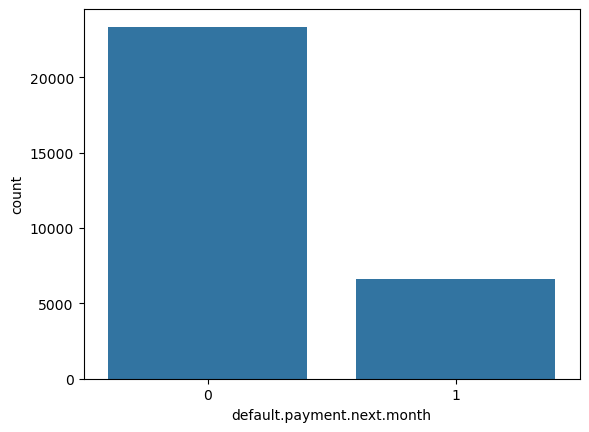

In [9]:
sns.countplot(x="default.payment.next.month", data=df)
plt.show()

In [10]:
df['LIMIT_BAL']. describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

In [11]:
range=df["LIMIT_BAL"].max() - df["LIMIT_BAL"].min()
range

990000.0

In [12]:
df['LIMIT_BAL'].skew()

np.float64(0.9928669605195444)

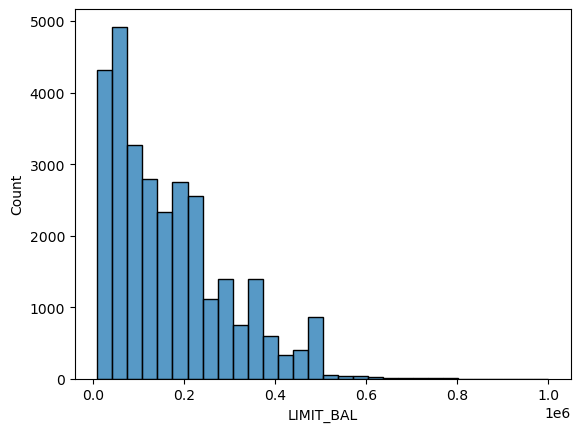

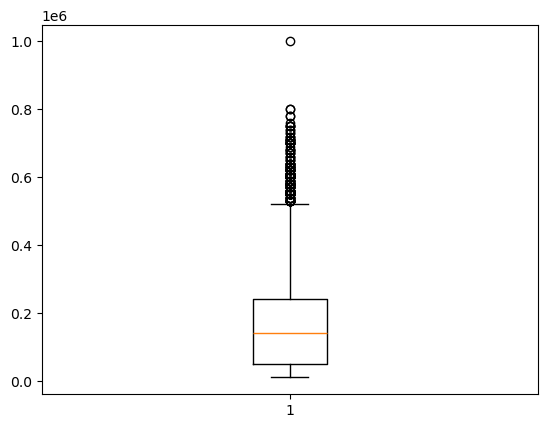

In [13]:
sns.histplot(df["LIMIT_BAL"], bins=30)
plt.show()

plt.boxplot(x=df["LIMIT_BAL"])
plt.show()

In [14]:
df["AGE"].describe()

count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

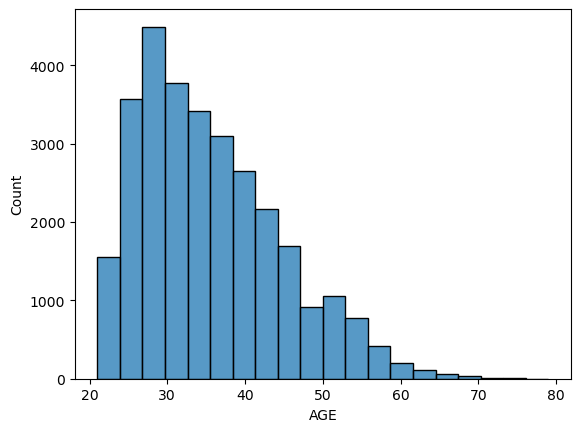

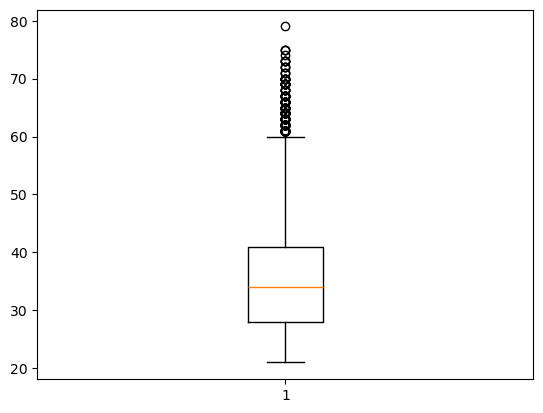

In [15]:
sns.histplot(df["AGE"], bins=20)
plt.show()

plt.boxplot(x=df['AGE'])
plt.show()

In [16]:
df['AGE'].skew()

np.float64(0.7322458687830562)

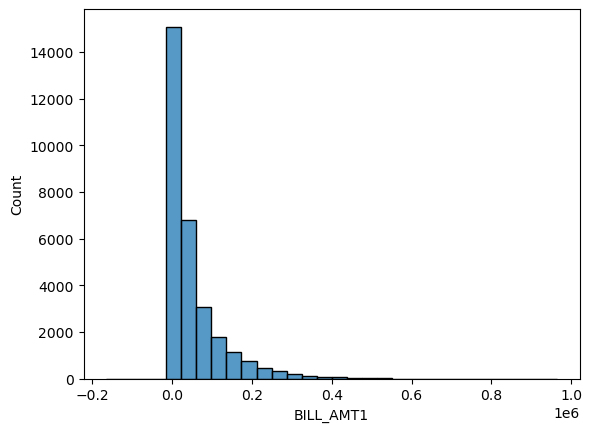

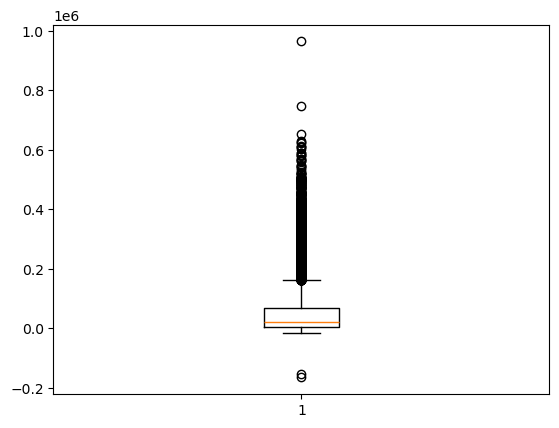

In [17]:
sns.histplot(df["BILL_AMT1"], bins=30)
plt.show()

plt.boxplot(x=df['BILL_AMT1'])
plt.show()

In [18]:
df['BILL_AMT1'].skew()

np.float64(2.6638610220232604)

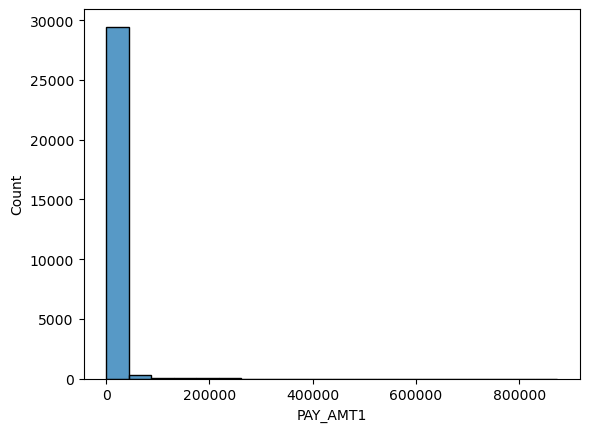

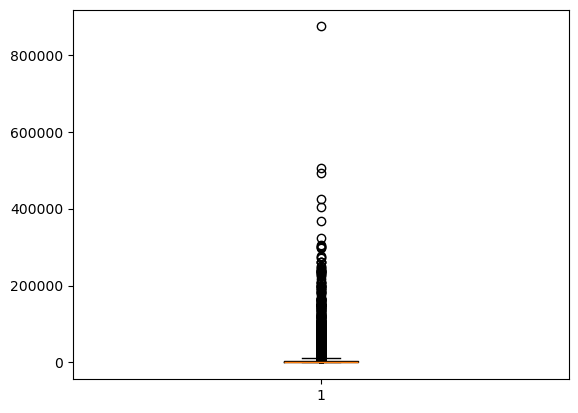

In [19]:
sns.histplot(df["PAY_AMT1"], bins=20)
plt.show()

plt.boxplot(x=df['PAY_AMT1'])
plt.show()

In [20]:
df["PAY_AMT1"].skew()
#highly right skewed

np.float64(14.66836433284317)

In [21]:
#Checking summary statistics together 
df[["BILL_AMT1","BILL_AMT2","BILL_AMT3",
    "BILL_AMT4","BILL_AMT5","BILL_AMT6"]].describe()


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400
std,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000
50%,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000
75%,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


In [22]:
#Checking skewness together
df[["BILL_AMT1","BILL_AMT2","BILL_AMT3",
    "BILL_AMT4","BILL_AMT5","BILL_AMT6"]].skew()

BILL_AMT1    2.663861
BILL_AMT2    2.705221
BILL_AMT3    3.087830
BILL_AMT4    2.821965
BILL_AMT5    2.876380
BILL_AMT6    2.846645
dtype: float64

In [23]:
#Checking summary statistics together 
df[["PAY_AMT1","PAY_AMT2","PAY_AMT3",
    "PAY_AMT4","PAY_AMT5","PAY_AMT6"]].describe()


,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


Most of the payment amounts are left skewed.

In [24]:
#Checking skewness together
df[["PAY_AMT1","PAY_AMT2","PAY_AMT3",
    "PAY_AMT4","PAY_AMT5","PAY_AMT6"]].skew()

PAY_AMT1    14.668364
PAY_AMT2    30.453817
PAY_AMT3    17.216635
PAY_AMT4    12.904985
PAY_AMT5    11.127417
PAY_AMT6    10.640727
dtype: float64

### Conclusion: I am going to use tree based models so I will skip the transformation of skewed variables in the dataset.

In [25]:
df["SEX"].value_counts(normalize=True).mul(100).round(2).astype(str)+'%'


SEX
2    60.37%
1    39.63%
Name: proportion, dtype: object

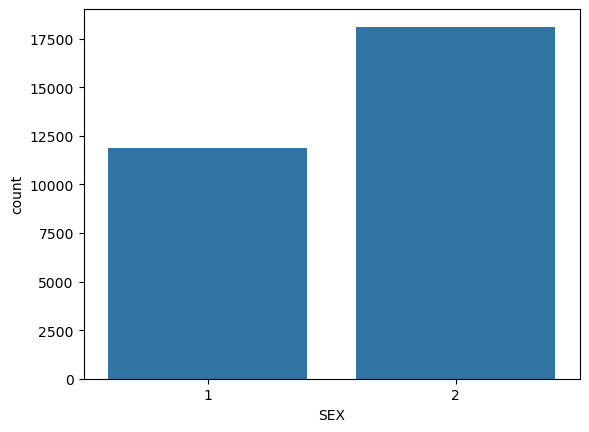

In [26]:
sns.countplot(x="SEX", data=df)
plt.show()

In [27]:
df['EDUCATION'].value_counts(normalize=True).mul(100).round(2).astype(str)+'%'

EDUCATION
2    46.77%
1    35.28%
3    16.39%
5     0.93%
4     0.41%
6     0.17%
0     0.05%
Name: proportion, dtype: object

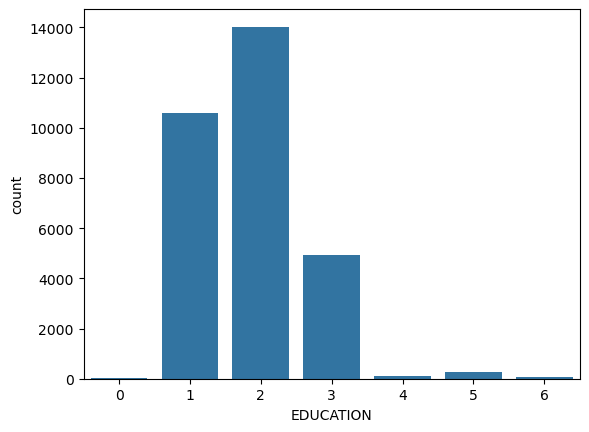

In [28]:
sns.countplot(x='EDUCATION',data=df)
plt.show()

In [29]:
df['MARRIAGE'].value_counts(normalize=True).mul(100).round(2).astype(str)+'%'

MARRIAGE
2    53.21%
1    45.53%
3     1.08%
0     0.18%
Name: proportion, dtype: object

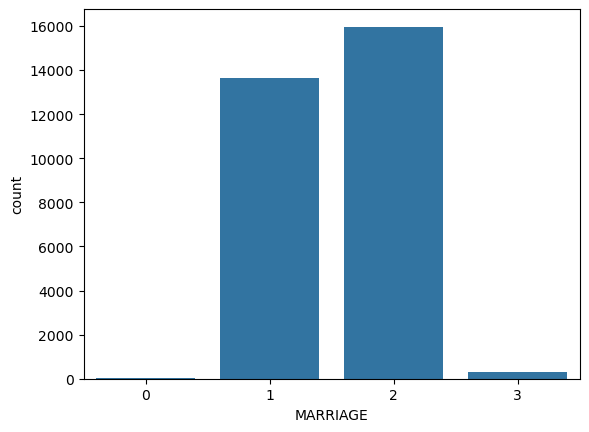

In [30]:
sns.countplot(x='MARRIAGE',data=df)
plt.show()

## Bivariate Analysis

We will see what actually influences defaults.

In [31]:
#SEX vs Default
pd.crosstab(df["SEX"], df["default.payment.next.month"], normalize="index") * 100

default.payment.next.month,0,1
SEX,,
1,75.832773,24.167227
2,79.223719,20.776281


In [32]:
#MARRIAGE vs Default
pd.crosstab(df["MARRIAGE"], df["default.payment.next.month"], normalize="index") * 100

default.payment.next.month,0,1
MARRIAGE,,
0,90.740741,9.259259
1,76.528296,23.471704
2,79.071661,20.928339
3,73.993808,26.006192


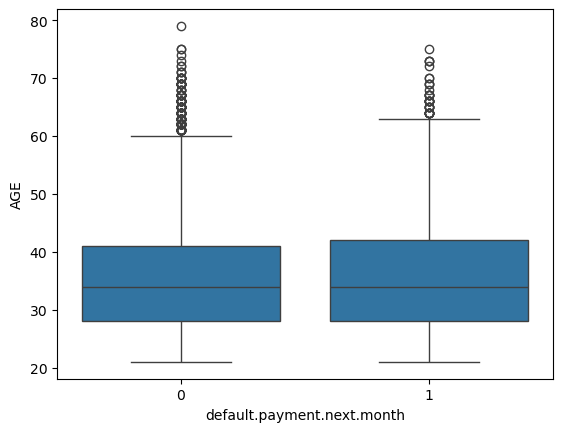

In [33]:
#AGE vs Default
sns.boxplot(x="default.payment.next.month", y="AGE", data=df)
plt.show()

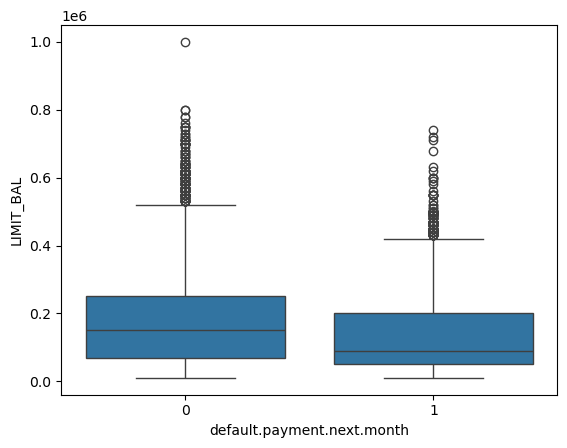

In [35]:
#LIMIT_BAL vs Default
sns.boxplot(x="default.payment.next.month", y="LIMIT_BAL", data=df)
plt.show()

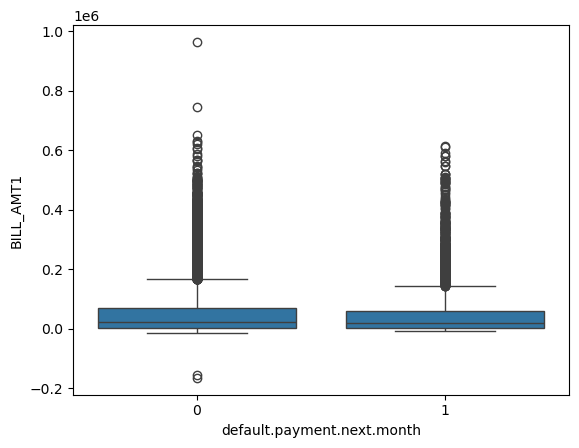

In [36]:
#BILL_AMT1 vs Default


sns.boxplot(x="default.payment.next.month", y="BILL_AMT1", data=df)
plt.show()

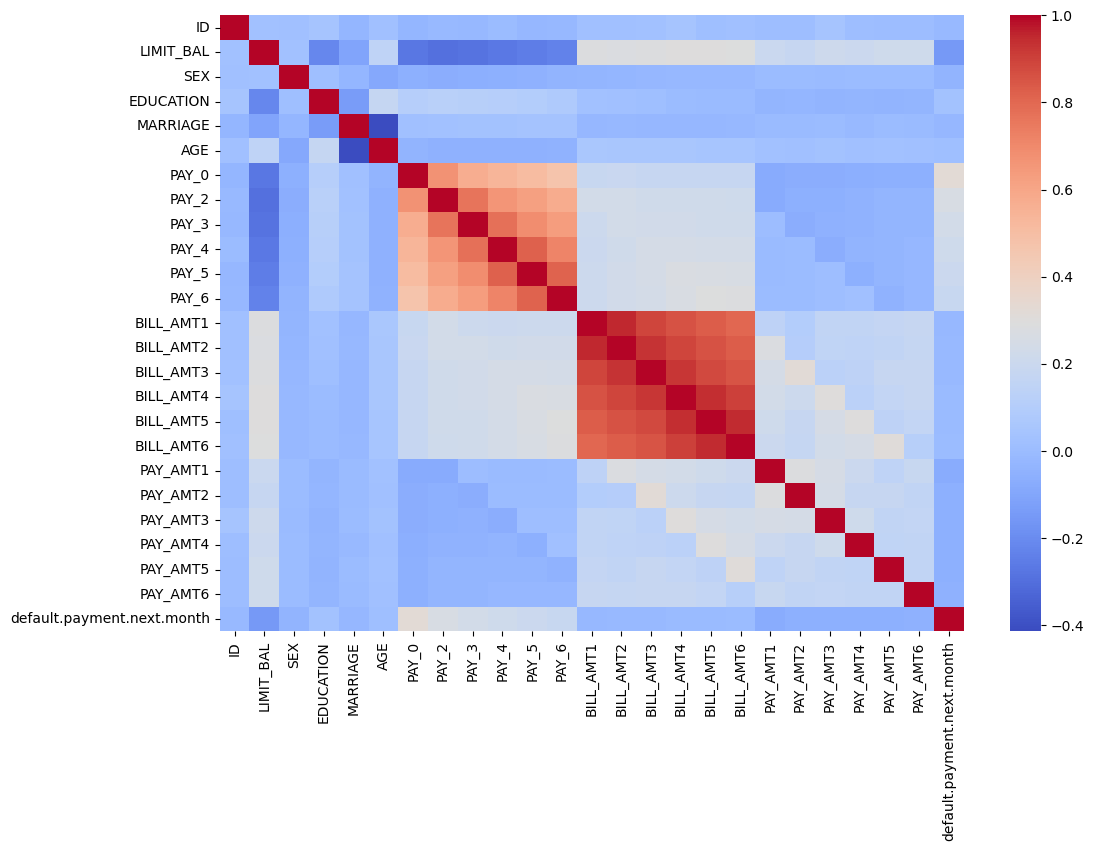

In [37]:
#Correlation Matrix (For Numerical Only)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

## Checking Missing Values

In [38]:
(df.isnull().sum()/len(df))*100

ID                            0.0
LIMIT_BAL                     0.0
SEX                           0.0
EDUCATION                     0.0
MARRIAGE                      0.0
AGE                           0.0
PAY_0                         0.0
PAY_2                         0.0
PAY_3                         0.0
PAY_4                         0.0
PAY_5                         0.0
PAY_6                         0.0
BILL_AMT1                     0.0
BILL_AMT2                     0.0
BILL_AMT3                     0.0
BILL_AMT4                     0.0
BILL_AMT5                     0.0
BILL_AMT6                     0.0
PAY_AMT1                      0.0
PAY_AMT2                      0.0
PAY_AMT3                      0.0
PAY_AMT4                      0.0
PAY_AMT5                      0.0
PAY_AMT6                      0.0
default.payment.next.month    0.0
dtype: float64

## Checking outliers

In [39]:
#Using IQR (Most common in EDA)
Q1 = df["LIMIT_BAL"].quantile(0.25)
Q3 = df["LIMIT_BAL"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count = ((df["LIMIT_BAL"] < lower) | 
                 (df["LIMIT_BAL"] > upper)).sum()

outlier_count

np.int64(167)

In [40]:
Q1 = df["BILL_AMT1"].quantile(0.25)
Q3 = df["BILL_AMT1"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count_billamount = ((df["BILL_AMT1"] < lower) | 
                 (df["BILL_AMT1"] > upper)).sum()

outlier_count_billamount

np.int64(2400)

In [41]:
#Deleting unnecessary columns
df = df.drop("ID", axis=1)

In [42]:
df.head(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [43]:
df.rename(columns={"default.payment.next.month": "default_payment_next_month"}, inplace=True)

In [44]:
df.head()


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [45]:
#saving processed dataset
df.to_csv(r"C:\Users\nidhi\Desktop\credit_default_project\data\EDA_processed\cleaned_data.csv", index=False)

# Project Folder Structure (Modular Architecture)